In [ ]:
# darts, but imputing missing values in a very naive way. attempting to use disjoint time series

In [ ]:
import pandas as pd
from darts import TimeSeries
from darts.utils.missing_values import fill_missing_values, missing_values_ratio
from darts.dataprocessing.transformers import MissingValuesFiller

In [ ]:
df_pivot = pd.read_csv('../../data/Daily_Means_Through_2022_cleaned_NEW.csv')
df_pivot

In [ ]:
# housekeeping
df_pivot['date'] = pd.to_datetime(df_pivot['date'])
df_new = df_pivot.sort_values(by=['site', 'date'])
df_new


In [ ]:
# get NaNs by site
sites = df_new['site'].unique()
for site in sites:
    df_site = df_new[df_new['site'] == site]
    print(site)
    print(len(df_site))
    print(df_site.isnull().sum())

In [ ]:
df_tw = df_new[df_new['site'] == 'TW']
dfs_by_year = {year: group for year, group in df_tw.groupby(df_tw["date"].dt.year)}
dfs_by_year

In [ ]:
print(df_tw.isnull().sum())

In [ ]:
for year, df in dfs_by_year.items():
    print(df.isnull().sum())

In [ ]:
print(dfs_by_year.keys())

In [ ]:
dfs_by_year[2007]

In [ ]:
# process each year HEAVY IMPUTATION
series_by_year = {}
for year, df in dfs_by_year.items():
    # create a TimeSeries object
    ts = TimeSeries.from_dataframe(df, time_col='date', value_cols=['bottom_DO_mg/L', 'surface_DO_mg/L',
       'bottom_Density_g/cm3', 'surface_Density_g/cm3', 'bottom_Depth_m',
       'surface_Depth_m', 'bottom_Salinity_ppt', 'surface_Salinity_ppt',
       'bottom_Temp_C', 'surface_Temp_C', 'bottom_pH', 'surface_pH'], freq="D", fill_missing_dates=True)
    
    ts = fill_missing_values(ts, fill='auto')
    # print nan proportion
    print(f"NaN proportion: {missing_values_ratio(ts)} for year {year}")
    
    # fill remaining NaN values with a straight up zero (BAD BAD BAD)
    df = ts.pd_dataframe()
    
    # get NaN in DO columns
    print(df.isnull().sum())
    
   #  ts_df.fillna(0, inplace=True)
    
   #  ts = TimeSeries.from_dataframe(ts_df, time_col='date', value_cols=['bottom_DO_mg/L', 'surface_DO_mg/L',
   #     'bottom_Density_g/cm3', 'surface_Density_g/cm3', 'bottom_Depth_m',
   #     'surface_Depth_m', 'bottom_Salinity_ppt', 'surface_Salinity_ppt',
   #     'bottom_Temp_C', 'surface_Temp_C', 'bottom_pH', 'surface_pH'], freq="D", fill_missing_dates=True)
    
   
    
    ts = TimeSeries.from_dataframe(df, value_cols=['bottom_DO_mg/L', 'surface_DO_mg/L',
       'bottom_Density_g/cm3', 'surface_Density_g/cm3', 'bottom_Depth_m',
       'surface_Depth_m', 'bottom_Salinity_ppt', 'surface_Salinity_ppt',
       'bottom_Temp_C', 'surface_Temp_C', 'bottom_pH', 'surface_pH'], freq="D", fill_missing_dates=True, fillna_value=1)
    
    print(f"new NaN proportion: {missing_values_ratio(ts)} for year {year}")
    # store the series
    series_by_year[year] = ts
#series_by_year

In [ ]:
# # process each year
# series_by_year = {}
# for year, df in dfs_by_year.items():
#     # create a TimeSeries object
#     ts = TimeSeries.from_dataframe(df, time_col='date', value_cols=['bottom_DO_mg/L', 'surface_DO_mg/L',
#        'bottom_Density_g/cm3', 'surface_Density_g/cm3', 'bottom_Depth_m',
#        'surface_Depth_m', 'bottom_Salinity_ppt', 'surface_Salinity_ppt',
#        'bottom_Temp_C', 'surface_Temp_C', 'bottom_pH', 'surface_pH'], freq="D", fill_missing_dates=True)
    
#     print(df.isna().sum())
#     print(len(df))
    
#     # store the series
#     series_by_year[year] = ts

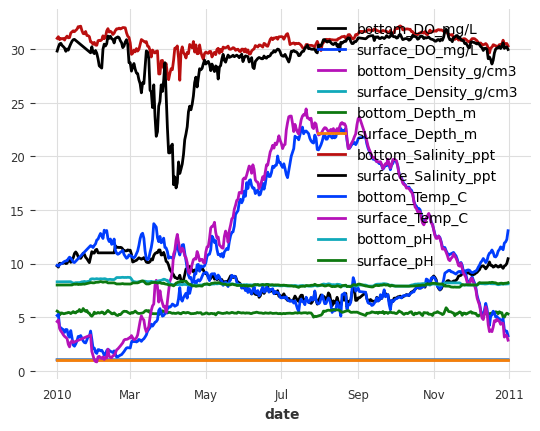

In [ ]:
# plot first year
series_by_year[2010].plot(max_nr_components=-1)

In [ ]:
for series in series_by_year.values():
    print(missing_values_ratio(series[0]))

In [ ]:
train = []
test = []
for year, ts in series_by_year.items():
    if year % 3:
        train.append(ts)
        print(year)
    else:
        test.append(ts)

In [ ]:
len(train), len(test)

In [ ]:
print(series_by_year.keys())

In [ ]:
from darts.metrics import mape
from darts.models import LinearRegressionModel, XGBModel, RandomForest, Prophet, KalmanForecaster, LightGBMModel, VARIMA

# length_test = 0
# for ts in test:
#     length_test += len(ts)
# last_year = train[-1]

def eval_model(model):
    model.fit(train)
    forecast = model.predict(len(series_by_year[2010]), series=series_by_year[2009])
    print(f"model {model} obtains MAPE: {mape(series_by_year[2010]["bottom_DO_mg/L"], forecast["bottom_DO_mg/L"]):.2f}%")
    #print(mape(test, forecast))
    
    forecast = model.predict(len(series_by_year[2013]), series=series_by_year[2012])
    print(f"model {model} obtains MAPE: {mape(series_by_year[2013]["bottom_DO_mg/L"], forecast["bottom_DO_mg/L"]):.2f}%")
    
    forecast = model.predict(len(series_by_year[2016]), series=series_by_year[2015])
    print(f"model {model} obtains MAPE: {mape(series_by_year[2016]["bottom_DO_mg/L"], forecast["bottom_DO_mg/L"]):.2f}%")


#eval_model(RandomForest(lags=10, n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5))
eval_model(LinearRegressionModel(lags=10))
print("done")
#eval_model(XGBModel(lags=10, n_estimators=50))
# #eval_model(RandomForest(lags=50, n_estimators=11))
# # eval_model(LightGBMModel(lags=112, n_estimators=5))
eval_model(VARIMA(p=12, d=0, q=0))




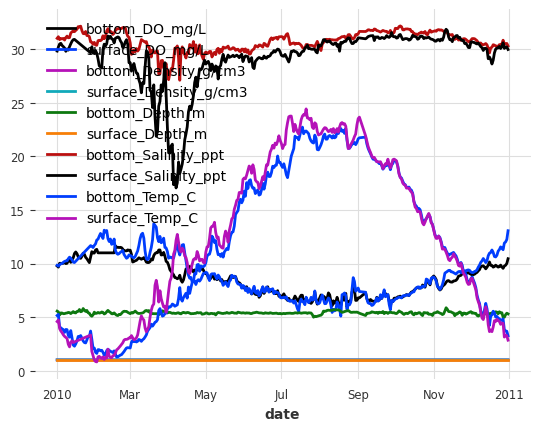

In [ ]:
series_by_year[2010].plot()

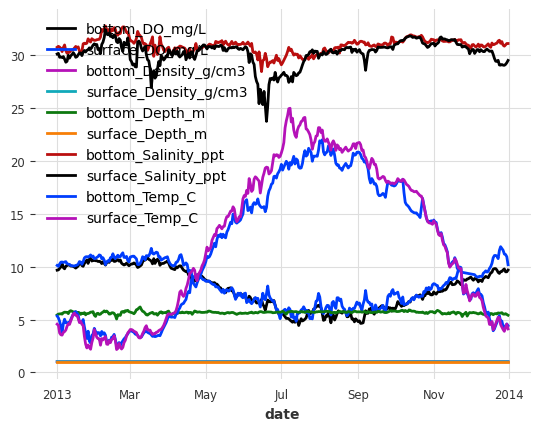

In [ ]:
series_by_year[2013].plot()

In [ ]:
for series in train:
    print(missing_values_ratio(series))
    
for series in test:
    print(missing_values_ratio(series))

In [ ]:
for series in train:
    print(missing_values_ratio(fill_missing_values(series, fill='auto')))

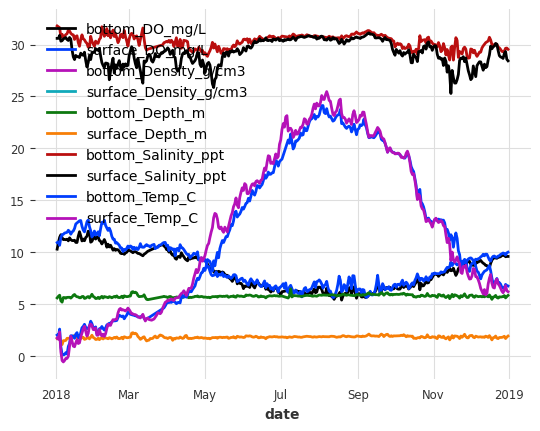

In [ ]:
test[0].plot()

In [ ]:
for series in test:
    print(series.gaps)

In [ ]:
test[0].gaps

In [ ]:
test[0].components

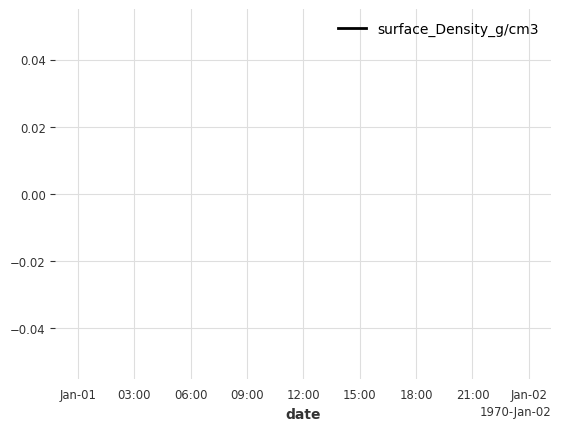

In [ ]:
test[0]["surface_Density_g/cm3"].plot()